# Settings

In [1]:
library(dplyr)
library(gplots)
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




In [2]:
# Input files
# - rowdata gene table from
rowdata.file <- "../rowdata_mouse.rds"
# - rowdata column to use for matching
match.col <- "gene_id_base"
# - unformatted expression data 
expr.file <- "../../input_data/Cardoso-Moreira/Mouse.RPKM.txt"

# Output files
out.files <- list("coldata" = "coldata_mouse.rds",
                  "exprmat" = "exprmat_mouse.rds",
                  "layout" = "layout_mouse.rds")

# Load input data

In [3]:
rowdata <- readRDS(rowdata.file)
nrow(rowdata)
head(rowdata)

[1] 42319

,source,type,gene_id,gene_type,gene_name,level,havana_gene,tag,gene_id_base,chr,⋯,hem_early_adult,sucessful_procedures_13,ortholog,hgnc_id,gene_symbol,mean_depmap_gene_effect_score,depmap_essential_05,depmap_essential_1,fusil_all,fusil
,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
MGI:1918911,HAVANA,gene,ENSMUSG00000109644.4,lncRNA,0610005C13Rik,2,OTTMUSG00000030340.1,NA,ENSMUSG00000109644,chr7,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1923503,HAVANA,gene,ENSMUSG00000108652.3,lncRNA,0610006L08Rik,2,OTTMUSG00000058385.1,overlapping_locus,ENSMUSG00000108652,chr7,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:3698435,HAVANA,gene,ENSMUSG00000086714.4,lncRNA,0610009E02Rik,2,OTTMUSG00000012797.1,overlapping_locus,ENSMUSG00000086714,chr2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1914088,HAVANA,gene,ENSMUSG00000043644.7,lncRNA,0610009L18Rik,2,OTTMUSG00000004146.1,NA,ENSMUSG00000043644,chr11,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1915609,HAVANA,gene,ENSMUSG00000020831.19,protein_coding,0610010K14Rik,2,OTTMUSG00000006039.1,overlapping_locus,ENSMUSG00000020831,chr11,⋯,NA,NA,one2one,HGNC:28737,C17orf49,-0.3500019,n,n,DL,DL
MGI:1918926,HAVANA,gene,ENSMUSG00000089755.2,lncRNA,0610012D04Rik,2,OTTMUSG00000028524.1,NA,ENSMUSG00000089755,chr17,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [4]:
exprdata <- read.delim(expr.file, sep=" ", as.is=T)
nrow(exprdata)
head(exprdata)

[1] 36141

,Brain.e10.5.1,Brain.e10.5.2,Brain.e10.5.3,Brain.e11.5.1,Brain.e11.5.2,Brain.e11.5.3,Brain.e11.5.4,Brain.e12.5.1,Brain.e12.5.2,Brain.e12.5.3,⋯,Testis.P0.1,Testis.P0.2,Testis.P3.1,Testis.P3.2,Testis.P14.1,Testis.P14.2,Testis.P28.1,Testis.P28.2,Testis.P63.1,Testis.P63.2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000001,91.249025,71.65777,74.720227,92.551938,110.268960,108.369090,100.500835,63.0262381,65.31800284,76.184423,⋯,47.987620,49.1677423,50.9325233,51.1055683,46.171858,45.005005,19.096970,18.774940,15.813911,19.438158
ENSMUSG00000000003,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000000,0.000000,⋯,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000000028,32.918534,32.02604,29.954786,26.165565,29.756235,28.587949,28.503567,16.8526727,15.61284894,14.501616,⋯,14.475879,14.9901436,18.8555955,15.9459651,31.819600,30.584024,20.677038,19.736960,18.160910,16.555893
ENSMUSG00000000037,1.654062,1.45529,1.381861,1.844178,1.981429,2.013843,1.751518,1.4633177,1.72751663,2.065834,⋯,7.174336,9.0163083,13.4879879,13.7013777,33.146548,30.636767,5.914366,5.779355,4.520455,6.596263
ENSMUSG00000000049,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0183573,0.01943419,0.000000,⋯,1.006715,0.3931789,0.1994612,0.2156769,0.000000,1.788117,28.037713,26.964063,29.337485,43.992037
ENSMUSG00000000056,17.452209,17.42198,18.349462,16.022810,17.645179,16.143452,15.543460,19.9826006,19.70454245,20.996124,⋯,9.756168,8.4052047,8.0341617,8.3303746,5.506498,5.232462,1.883225,2.014495,2.039691,1.931738


# Make coldata table

In [5]:
samples <- colnames(exprdata)
samples <- gsub("e10.5", "e10-5", samples)
samples <- gsub("e11.5", "e11-5", samples)
samples <- gsub("e12.5", "e12-5", samples)
samples <- gsub("e13.5", "e13-5", samples)
samples <- gsub("e14.5", "e14-5", samples)
samples <- gsub("e15.5", "e15-5", samples)
samples <- gsub("e16.5", "e16-5", samples)
samples <- gsub("e17.5", "e17-5", samples)
samples <- gsub("e18.5", "e18-5", samples)
coldata <- samples %>% strsplit(split="\\.") %>%
    lapply(FUN=strsplit, split="\\.") %>%
    unlist() %>%
    matrix(ncol=3, byrow=T) %>%
    as.data.frame()
coldata <- cbind(samples, coldata)
colnames(coldata) <- c("label_adj","tissue", "stage", "index")
rownames(coldata) <- gsub("\\.", "_", samples)
coldata$label <- colnames(exprdata)
nrow(coldata)
head(coldata)
table(coldata$stage)
table(coldata$tissue)

[1] 316

,label_adj,tissue,stage,index,label
,<chr>,<chr>,<chr>,<chr>,<chr>
Brain_e10-5_1,Brain.e10-5.1,Brain,e10-5,1,Brain.e10.5.1
Brain_e10-5_2,Brain.e10-5.2,Brain,e10-5,2,Brain.e10.5.2
Brain_e10-5_3,Brain.e10-5.3,Brain,e10-5,3,Brain.e10.5.3
Brain_e11-5_1,Brain.e11-5.1,Brain,e11-5,1,Brain.e11.5.1
Brain_e11-5_2,Brain.e11-5.2,Brain,e11-5,2,Brain.e11.5.2
Brain_e11-5_3,Brain.e11-5.3,Brain,e11-5,3,Brain.e11.5.3



e10-5 e11-5 e12-5 e13-5 e14-5 e15-5 e16-5 e17-5 e18-5    P0   P14   P28    P3 
   15    20    20    25    22    24    24    24    23    24    23    24    24 
  P63 
   24 


     Brain Cerebellum      Heart     Kidney      Liver      Ovary     Testis 
        55         43         55         51         57         28         27 

In [6]:
# Add replicate column
coldata$replicate <- NA
tissues <- unique(coldata$tissue)
stages <- unique(coldata$stage)
for(t in seq(length(tissues))){
    for(s in seq(length(stages))){
        temp.match <- which(coldata$tissue==tissues[t] & coldata$stage==stages[s])
        coldata[temp.match, "replicate"] <- seq(length(temp.match))
    }
}
nrow(coldata)
head(coldata)

[1] 316

,label_adj,tissue,stage,index,label,replicate
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
Brain_e10-5_1,Brain.e10-5.1,Brain,e10-5,1,Brain.e10.5.1,1
Brain_e10-5_2,Brain.e10-5.2,Brain,e10-5,2,Brain.e10.5.2,2
Brain_e10-5_3,Brain.e10-5.3,Brain,e10-5,3,Brain.e10.5.3,3
Brain_e11-5_1,Brain.e11-5.1,Brain,e11-5,1,Brain.e11.5.1,1
Brain_e11-5_2,Brain.e11-5.2,Brain,e11-5,2,Brain.e11.5.2,2
Brain_e11-5_3,Brain.e11-5.3,Brain,e11-5,3,Brain.e11.5.3,3


# Make counts table

In [7]:
#match rowdata with exprdata
m <- match(rowdata[,match.col], rownames(exprdata))

# check matches
length(m)
length(which(is.na(m))) # how many NAs?
all(rowdata[which(!is.na(m)),match.col] == rownames(exprdata)[m[which(!is.na(m))]]) # all non-NAs match correctly?

[1] 42319

[1] 16091

[1] TRUE

In [8]:
# make exprmat
exprmat <- matrix(NA, nrow=nrow(rowdata), ncol=nrow(coldata))
rownames(exprmat) <- rownames(rowdata)
colnames(exprmat) <- rownames(coldata)
exprmat[,rownames(coldata)]  <- as.matrix(exprdata[m,coldata[rownames(coldata),"label"]])
nrow(exprmat)
head(exprmat)

[1] 42319

,Brain_e10-5_1,Brain_e10-5_2,Brain_e10-5_3,Brain_e11-5_1,Brain_e11-5_2,Brain_e11-5_3,Brain_e11-5_4,Brain_e12-5_1,Brain_e12-5_2,Brain_e12-5_3,⋯,Testis_P0_1,Testis_P0_2,Testis_P3_1,Testis_P3_2,Testis_P14_1,Testis_P14_2,Testis_P28_1,Testis_P28_2,Testis_P63_1,Testis_P63_2
MGI:1918911,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1923503,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:3698435,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1914088,0.6558143,1.013613,1.186801,1.104334,0.9965512,0.702747,0.9312692,2.221797,1.851679,2.089958,⋯,1.882164,2.163032,2.168688,2.019615,3.693751,4.779476,29.848255,42.4197795,24.14407173,55.4457420
MGI:1915609,1.1034804,2.084802,1.398236,2.163237,1.0787949,1.130765,1.2876895,1.990896,1.895284,2.146821,⋯,1.495628,1.502510,1.266995,1.516522,1.231582,1.255922,0.197529,0.1547383,0.08475784,0.2865025
MGI:1918926,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


# Average across replicates

In [9]:
exprmat.avg <- matrix(NA, nrow=nrow(exprmat), ncol=0)
coldata.avg <- as.data.frame(matrix(NA, nrow=0, ncol=4))
rownames(exprmat.avg) <- rownames(exprmat)
for(t in seq(length(tissues))){
    for(s in seq(length(stages))){
        temp.match <- which(coldata$tissue==tissues[t] & coldata$stage==stages[s])
        if(length(temp.match)==1){
            exprmat.avg <-  cbind(exprmat.avg, exprmat[,temp.match])
            colnames(exprmat.avg)[ncol(exprmat.avg)] <- paste(tissues[t], stages[s], sep="_")}
        if(length(temp.match)>1){
            exprmat.avg <-  cbind(exprmat.avg, rowMeans(exprmat[,temp.match]))
            colnames(exprmat.avg)[ncol(exprmat.avg)] <- paste(tissues[t], stages[s], sep="_")}
        if(length(temp.match)>0){
            coldata.avg <- rbind(coldata.avg, c(paste(tissues[t], stages[s], sep="_"),
                                                tissues[t], stages[s]))}
    }
}
nrow(exprmat.avg)
ncol(exprmat.avg)
head(exprmat.avg)
colnames(coldata.avg) <- c("label", "tissue", "stage")
rownames(coldata.avg) <- coldata.avg$label
nrow(coldata.avg)
head(coldata.avg)

[1] 42319

[1] 94

,Brain_e10-5,Brain_e11-5,Brain_e12-5,Brain_e13-5,Brain_e14-5,Brain_e15-5,Brain_e16-5,Brain_e17-5,Brain_e18-5,Brain_P0,⋯,Testis_e14-5,Testis_e15-5,Testis_e16-5,Testis_e17-5,Testis_e18-5,Testis_P0,Testis_P3,Testis_P14,Testis_P28,Testis_P63
MGI:1918911,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1923503,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:3698435,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1914088,0.952076,0.9337255,1.977352,1.914782,2.202334,2.184045,2.214051,1.645975,2.751750,2.714415,⋯,1.631748,1.543339,1.163675,1.965383,1.184808,2.022598,2.094151,4.236613,36.1340171,39.7949069
MGI:1915609,1.528840,1.4151217,1.977678,1.847951,1.824117,1.965886,1.681156,1.480902,1.517822,1.501562,⋯,1.194955,1.468448,1.411271,1.233952,1.474723,1.499069,1.391758,1.243752,0.1761336,0.1856302
MGI:1918926,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 94

,label,tissue,stage
,<chr>,<chr>,<chr>
Brain_e10-5,Brain_e10-5,Brain,e10-5
Brain_e11-5,Brain_e11-5,Brain,e11-5
Brain_e12-5,Brain_e12-5,Brain,e12-5
Brain_e13-5,Brain_e13-5,Brain,e13-5
Brain_e14-5,Brain_e14-5,Brain,e14-5
Brain_e15-5,Brain_e15-5,Brain,e15-5


# format layout

In [10]:
# correct stage labeling to make consitent across tissues (not needed here)
coldata.avg.reformat <- coldata.avg
tissues.reformat <- unique(coldata.avg.reformat$tissue)
stages.reformat <- unique(coldata.avg.reformat$stage)
tissues.reformat
stages.reformat

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

[1] "e10-5" "e11-5" "e12-5" "e13-5" "e14-5" "e15-5" "e16-5" "e17-5" "e18-5"
[10] "P0"    "P3"    "P14"   "P28"   "P63"

In [11]:
# Filter tissues and/or stages in final layout [optional, not done in this case]
# - tissues to keep (all in this case)
tissues.sub <- tissues.reformat
# - stages to keep (all in this case)
stages.sub <- stages.reformat

keep.rows <- c()
for(t in seq(length(tissues.sub))){
    for(s in seq(length(stages.sub))){
        temp.match <- which(coldata.avg.reformat$tissue==tissues.sub[t] & coldata.avg.reformat$stage==stages.sub[s])
        if(length(temp.match)==1){
            keep.rows <- c(keep.rows, temp.match)}
    }
}
coldata.avg.reformat.filt <- coldata.avg.reformat[keep.rows,]
nrow(coldata.avg.reformat.filt)
coldata.avg.reformat.filt

[1] 94

,label,tissue,stage
,<chr>,<chr>,<chr>
Brain_e10-5,Brain_e10-5,Brain,e10-5
Brain_e11-5,Brain_e11-5,Brain,e11-5
Brain_e12-5,Brain_e12-5,Brain,e12-5
Brain_e13-5,Brain_e13-5,Brain,e13-5
Brain_e14-5,Brain_e14-5,Brain,e14-5
Brain_e15-5,Brain_e15-5,Brain,e15-5
Brain_e16-5,Brain_e16-5,Brain,e16-5
Brain_e17-5,Brain_e17-5,Brain,e17-5
Brain_e18-5,Brain_e18-5,Brain,e18-5


In [12]:
# order stages for display (no change in this case)
length(stages.sub)
stages.sub
stages.sub.ord <- stages.sub
length(stages.sub.ord)
stages.sub.ord

[1] 14

[1] "e10-5" "e11-5" "e12-5" "e13-5" "e14-5" "e15-5" "e16-5" "e17-5" "e18-5"
[10] "P0"    "P3"    "P14"   "P28"   "P63"

[1] 14

[1] "e10-5" "e11-5" "e12-5" "e13-5" "e14-5" "e15-5" "e16-5" "e17-5" "e18-5"
[10] "P0"    "P3"    "P14"   "P28"   "P63"

In [13]:
# order tissuesfor display (no change in this case)
length(tissues.sub)
tissues.sub
tissues.sub.ord <- tissues.sub
length(tissues.sub.ord)
tissues.sub.ord

[1] 7

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

[1] 7

[1] "Brain"      "Cerebellum" "Heart"      "Kidney"     "Liver"     
[6] "Ovary"      "Testis"

Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Rowv is FALSE, while dendrogram is `both'. Omitting row dendogram.”
Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Colv is FALSE, while dendrogram is `column'. Omitting column dendogram.”


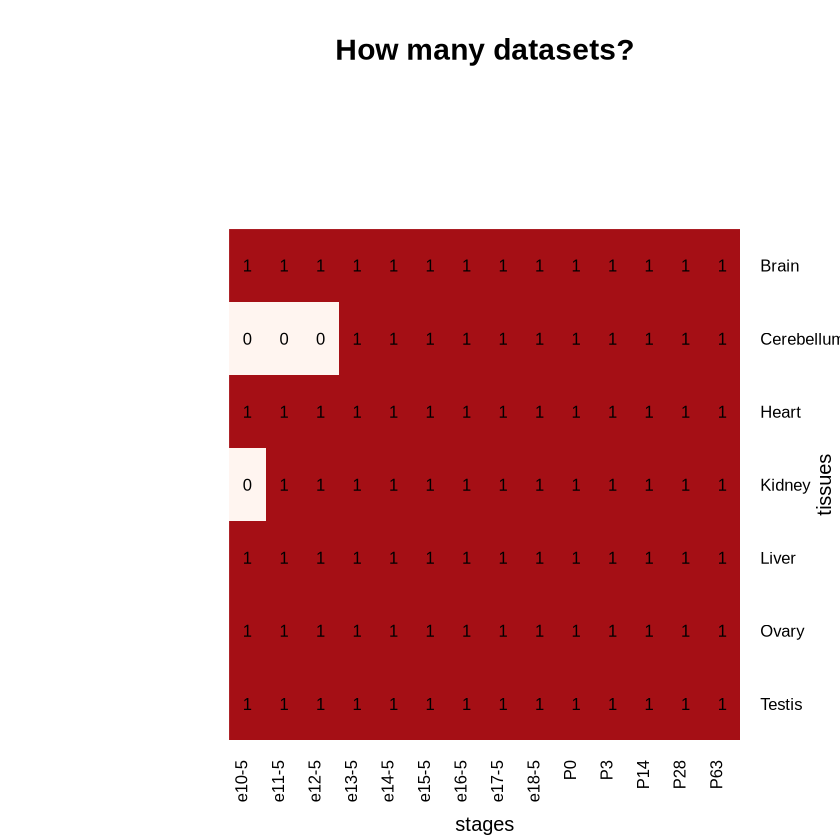

In [14]:
# plot layout as heatmap
my.cex=1
bias=1
my.pal <- c(brewer.pal(9, "Reds")[c(1,4,8)])
my.cols <- colorRampPalette(my.pal, bias=bias)(100)
layout.heatmap <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        layout.heatmap[row, col] <- length(which(coldata.avg.reformat.filt$tissue==tissues.sub.ord[row] & 
                                                 coldata.avg.reformat.filt$stage==stages.sub.ord[col]))
    }
}
heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col=my.cols, symbreaks=F,
          tracecol=NA, cexRow=my.cex, cexCol=my.cex, 
          xlab="stages", ylab="tissues", main="How many datasets?",
          labRow=tissues.sub, labCol=stages.sub, key=F, cellnote=round(layout.heatmap, digits=1), notecex=my.cex, notecol="black")

In [15]:
# create layout matrix by sample name
layout <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
rownames(layout) <- tissues.sub.ord
colnames(layout) <- stages.sub.ord
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        temp.match <- which(coldata.avg.reformat.filt$tissue==tissues.sub.ord[row] & 
                            coldata.avg.reformat.filt$stage==stages.sub.ord[col])
         if(length(temp.match) == 1){
              layout[row, col] <- coldata.avg.reformat.filt$label[temp.match]}
    }
}
layout

,e10-5,e11-5,e12-5,e13-5,e14-5,e15-5,e16-5,e17-5,e18-5,P0,P3,P14,P28,P63
Brain,Brain_e10-5,Brain_e11-5,Brain_e12-5,Brain_e13-5,Brain_e14-5,Brain_e15-5,Brain_e16-5,Brain_e17-5,Brain_e18-5,Brain_P0,Brain_P3,Brain_P14,Brain_P28,Brain_P63
Cerebellum,NA,NA,NA,Cerebellum_e13-5,Cerebellum_e14-5,Cerebellum_e15-5,Cerebellum_e16-5,Cerebellum_e17-5,Cerebellum_e18-5,Cerebellum_P0,Cerebellum_P3,Cerebellum_P14,Cerebellum_P28,Cerebellum_P63
Heart,Heart_e10-5,Heart_e11-5,Heart_e12-5,Heart_e13-5,Heart_e14-5,Heart_e15-5,Heart_e16-5,Heart_e17-5,Heart_e18-5,Heart_P0,Heart_P3,Heart_P14,Heart_P28,Heart_P63
Kidney,NA,Kidney_e11-5,Kidney_e12-5,Kidney_e13-5,Kidney_e14-5,Kidney_e15-5,Kidney_e16-5,Kidney_e17-5,Kidney_e18-5,Kidney_P0,Kidney_P3,Kidney_P14,Kidney_P28,Kidney_P63
Liver,Liver_e10-5,Liver_e11-5,Liver_e12-5,Liver_e13-5,Liver_e14-5,Liver_e15-5,Liver_e16-5,Liver_e17-5,Liver_e18-5,Liver_P0,Liver_P3,Liver_P14,Liver_P28,Liver_P63
Ovary,Ovary_e10-5,Ovary_e11-5,Ovary_e12-5,Ovary_e13-5,Ovary_e14-5,Ovary_e15-5,Ovary_e16-5,Ovary_e17-5,Ovary_e18-5,Ovary_P0,Ovary_P3,Ovary_P14,Ovary_P28,Ovary_P63
Testis,Testis_e10-5,Testis_e11-5,Testis_e12-5,Testis_e13-5,Testis_e14-5,Testis_e15-5,Testis_e16-5,Testis_e17-5,Testis_e18-5,Testis_P0,Testis_P3,Testis_P14,Testis_P28,Testis_P63


# write output

In [16]:
saveRDS(coldata.avg, file=out.files[["coldata"]])
saveRDS(exprmat.avg, file=out.files[["exprmat"]])
saveRDS(layout, file=out.files[["layout"]])